In [1]:
from functions import *
import os
import matplotlib.pyplot as plt
import corner
import matplotlib.gridspec as gridspec
import h5py
import matplotlib
from mpl_toolkits.axes_grid.inset_locator import inset_axes

#%matplotlib widget
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
for z in zlist:
    qlf = QLF(z, 0.01)

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/cbook/deprecation.py:107: MatplotlibDeprecationWarning: The mpl_toolkits.axes_grid module was deprecated in version 2.1. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist provies the same functionality instead.
  warnings.warn(message, mplDeprecation, stacklevel=1)


/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:214: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:218: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:205: RuntimeWarning: divide by zero encountered in log
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:234: RuntimeWarning: divide by zero encountered in log


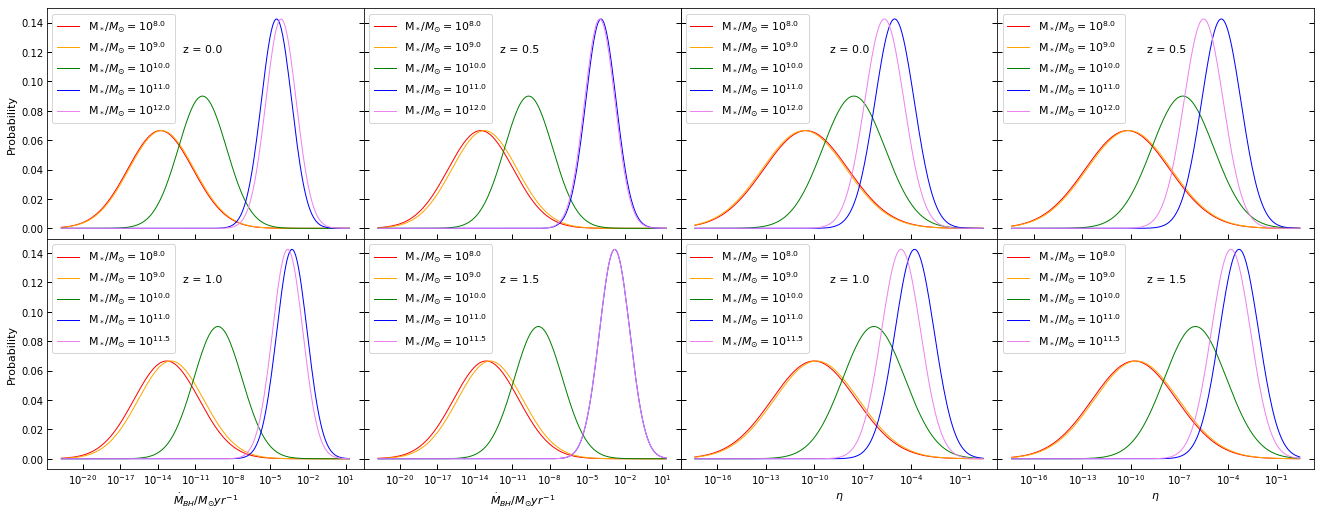

In [3]:
fig = plt.figure(figsize=(22,8))
zlist = [0.0, 0.5, 1.0, 1.5]
color = ['r','orange','green','blue','violet']
dlnMstar = 0.7
bins = 0.005
dM = 0.3
siglnX = [6.0,2.8]
fs = 11
tw = 1
tl = 5
lums = np.linspace(6,16,500)

######### AXIS 1
ax1 = fig.add_axes([0.5, 0.5, 0.2, 0.4])

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[0], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdotedd = qlf.Mdot_mu_sig[:,2]
lneta = lnMdot - lnMdotedd

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-40, 1, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lneta[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax1.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax1.text(10e-10,.12,'z = '+str(zlist[0]), fontsize = fs)
ax1.set_xscale('log')
ax1.axis([np.e**x[0],np.e**x[-1], 0, max(y)+0.01])
ax1.legend(loc='upper left',fontsize = fs)
ax1.tick_params(direction='in', width = tw, length = tl, right = True)
plt.setp(ax1.get_xticklabels(), visible=False)

######### AXIS 2
ax2 = fig.add_axes([0.7, 0.5, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[1], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdotedd = qlf.Mdot_mu_sig[:,2]
lneta = lnMdot - lnMdotedd

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-40, 1, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lneta[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax2.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax2.text(10e-10,.12,'z = '+str(zlist[1]), fontsize = fs)  
ax2.legend(loc='upper left',fontsize = fs)
ax2.tick_params(direction='in', width = tw, length = tl, right = True)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)


######### AXIS 3
ax3 = fig.add_axes([0.5, 0.1, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[2], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdotedd = qlf.Mdot_mu_sig[:,2]
lneta = lnMdot - lnMdotedd

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-40, 1, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lneta[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax3.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax3.text(10e-10,.12,'z = '+str(zlist[2]), fontsize = fs)  
ax3.legend(loc='upper left',fontsize = fs)
ax3.tick_params(direction='in', width = tw, length = tl, right = True)
ax3.set_xlabel(r'$\eta$', fontsize = fs)


######### AXIS 4
ax4 = fig.add_axes([0.7, 0.1, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[3], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdotedd = qlf.Mdot_mu_sig[:,2]
lneta = lnMdot - lnMdotedd

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-40, 1, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lneta[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax4.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax4.text(10e-10,.12,'z = '+str(zlist[3]), fontsize = fs)  
ax4.legend(loc='upper left',fontsize = fs)
ax4.tick_params(direction='in', width = tw, length = tl, right = True)
ax4.set_xlabel(r'$\eta$', fontsize = fs)
plt.setp(ax4.get_yticklabels(), visible=False)



######### AXIS 1
ax1 = fig.add_axes([0.1, 0.5, 0.2, 0.4], sharey = ax4)

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[0], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax1.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax1.text(10e-13,.12,'z = '+str(zlist[0]), fontsize = fs) 
ax1.set_xscale('log')
ax1.axis([np.e**x[0],np.e**x[-1], 0, max(y)+0.01])
ax1.set_ylabel(r'Probability', fontsize = fs)  
ax1.legend(loc='upper left',fontsize = fs)
ax1.tick_params(direction='in', width = tw, length = tl, right = True)
plt.setp(ax1.get_xticklabels(), visible=False)

######### AXIS 2
ax2 = fig.add_axes([0.3, 0.5, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[1], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax2.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax2.text(10e-13,.12,'z = '+str(zlist[1]), fontsize = fs)  
ax2.legend(loc='upper left',fontsize = fs)
ax2.tick_params(direction='in', width = tw, length = tl, right = True)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)


######### AXIS 3
ax3 = fig.add_axes([0.1, 0.1, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[2], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax3.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax3.text(10e-13,.12,'z = '+str(zlist[2]), fontsize = fs)  
ax3.legend(loc='upper left',fontsize = fs)
ax3.tick_params(direction='in', width = tw, length = tl, right = True)
ax3.set_xlabel(r'$\dot{M}_{BH}/M_{\odot} yr^{-1}$', fontsize = fs)
ax3.set_ylabel(r'Probability', fontsize = fs) 


######### AXIS 4
ax4 = fig.add_axes([0.3, 0.1, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[3], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(dlnMstar)
qlf.get_SMBM(dM)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax4.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax4.text(10e-13,.12,'z = '+str(zlist[3]), fontsize = fs)  
ax4.legend(loc='upper left',fontsize = fs)
ax4.tick_params(direction='in', width = tw, length = tl, right = True)
ax4.set_xlabel(r'$\dot{M}_{BH}/M_{\odot} yr^{-1}$', fontsize = fs)
plt.setp(ax4.get_yticklabels(), visible=False)


plt
plt.savefig('plots/paper-plots/distribution-both_forvarry_Mstar.pdf')

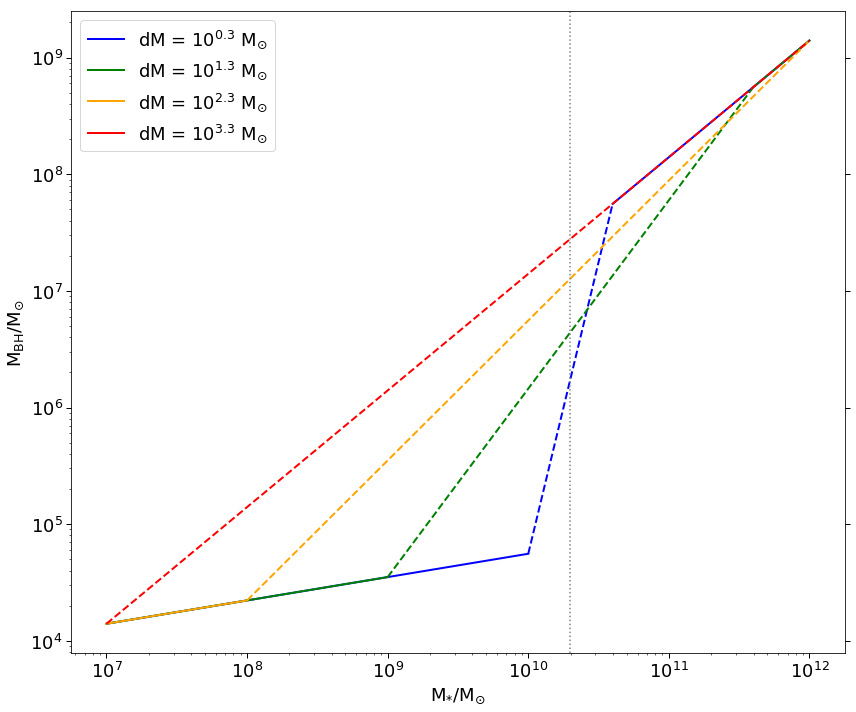

In [5]:
plt.close()
lw = 2
fs = 18
tw = 1
tl = 5

dM_list = [0.3, 1.3, 2.3, 3.3]
colors = ['blue','green','orange','red']

start = [7., np.log10(1.4*10**4.)]
stop = [12., np.log10(1.4*10**9.)]

fig = plt.figure(figsize=(12,10))

for dM, c in zip(dM_list, colors):
    qlf.get_SMBM(dM)
    massc = qlf.mass_cuts
    slopes = qlf.slope_list
    ints = qlf.int_list
    if massc[1] >= stop[0]:
        plt.plot([10**start[0], 10**massc[0]], [10**start[1], 10**(massc[0]*slopes[0]+ints[0])], c=c, lw = lw, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
        plt.plot([10**massc[0], 10**stop[0]], [10**(massc[0]*slopes[1]+ints[1]), 10**stop[1]], ls = 'dashed', lw = lw, c=c)
    else:
        plt.plot([10**massc[0], 10**massc[1]], [10**(massc[0]*slopes[1]+ints[1]), 10**(massc[1]*slopes[1]+ints[1])], ls = 'dashed', lw = lw, c=c)
        plt.plot([10**start[0], 10**massc[0]], [10**start[1], 10**(massc[0]*slopes[0]+ints[0])], c=c, lw = lw, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
        plt.plot([10**massc[1], 10**stop[0]], [10**(massc[1]*slopes[2]+ints[2]), 10**stop[1]], c=c, lw = lw)

plt.tick_params(direction='out', width = tw, length = tl, right = True, labelsize = fs)
plt.axvline(10**10.3, lw = 1.5, ls = 'dotted', c='grey')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'M$_{*}$/M$_{\odot}$', fontsize = fs)
plt.ylabel(r'M$_{\rm{BH}}$/M$_{\odot}$', fontsize = fs)
plt.legend(fontsize = fs)
plt.tight_layout()
plt.savefig('plots/paper-plots/dM-effects.pdf')


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


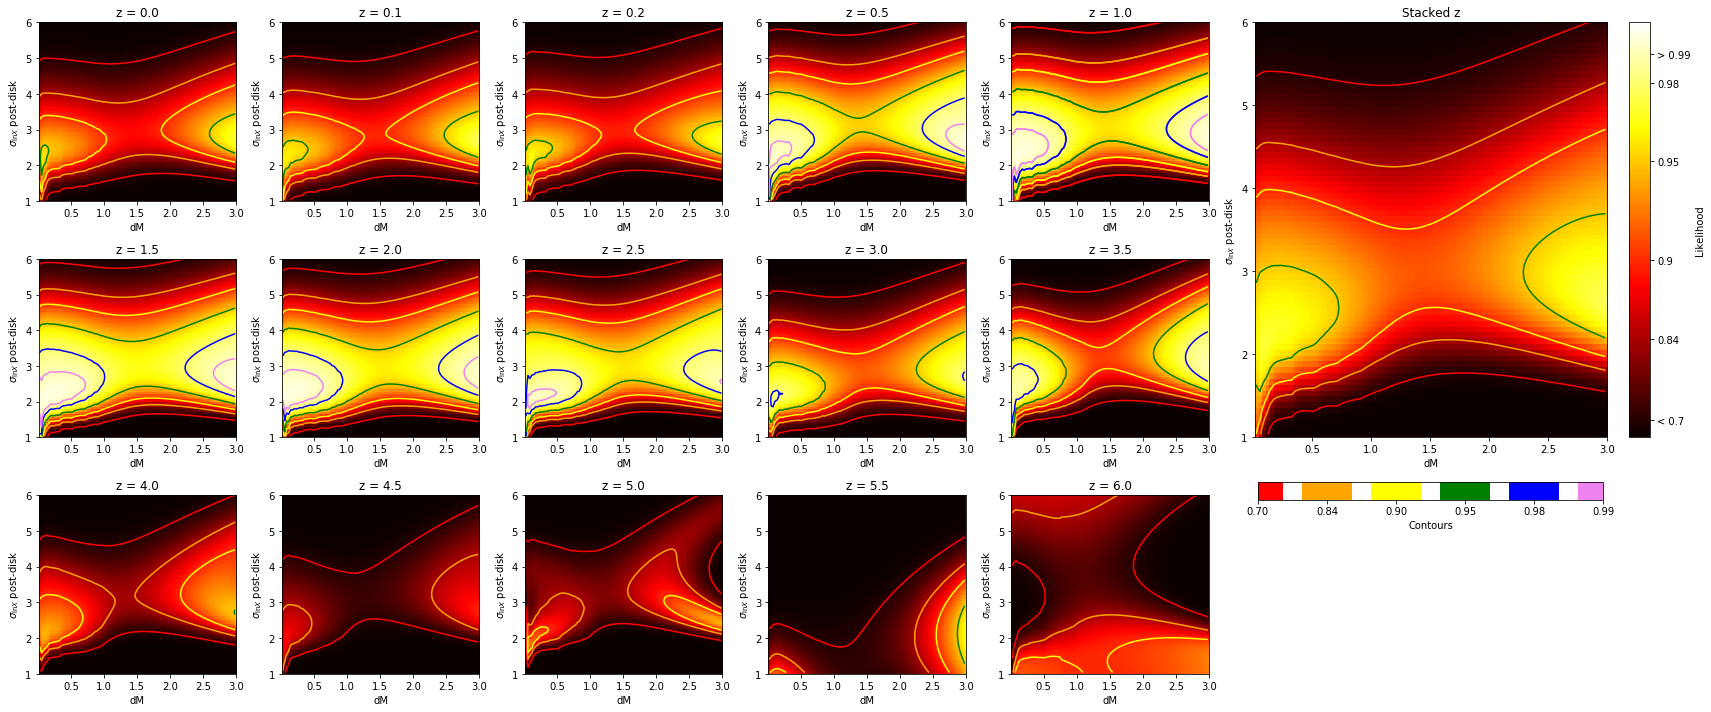

In [33]:
plt.close()

ticks = [0.70,0.84,0.90,0.95,0.98,0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]

gridcmap = 'hot'
contcmap = 'Pastel1'
contmin = 0.7
colors = ['red','orange','yellow','green','blue','violet']

f = h5py.File("Quest-emcee/chi2_grid_data_obsfix.h5py", "r")
extent = f['extent'][:]
bins = f.attrs['bins']
f.close()

totpoints = 732

fig = plt.figure(figsize=(24,10))
gs = gridspec.GridSpec(3, 7)
stack = np.zeros((bins, bins))
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):
    
    
    xa, ya, yerr = grab_obs(z)
    num_obs = len(xa)
    f = h5py.File("Quest-emcee/chi2_grid_data_obsfix.h5py", "r")
    grid2d = f['z='+str(z)+'/chi2_grid'][:]
    maxval = f['z='+str(z)+'/min-max'][:][1]
    numob = f['z='+str(z)+'/#_observation'][:][0]
    f.close()

    ax = fig.add_subplot(gs[i, j])
    maxl = []
    for n in grid2d:
        maxl.append(max(n))
    maxval = max(maxl)
    img = ax.imshow(np.e**(-grid2d/maxval), cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
    ax.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
    ax.set_xlabel('dM')
    ax.axis([0.01,3,1,6])
    ax.set_title('z = '+str(z))
#     plt.contour(np.e**(-grid2d/maxval), cmap=contcmap, extent = extent, origin = 'image', levels=ticks, vmin = contmin)
    plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)
    if z == 1.0:
#         cont1 = plt.contour(np.e**(-grid2d/maxval), cmap=contcmap, extent = extent, origin = 'image', levels=ticks, vmin = contmin)
        cont1 = plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)

    stack += np.e**(-grid2d/maxval) * (numob/totpoints)

    

ax1 = fig.add_subplot(gs[0:2,5:])

total = ax1.imshow(stack, cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=5), vmin = .36, vmax = 1)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax1.set_xlabel('dM')
ax1.axis([0.01,3,1,6])
ax1.set_title('Stacked z')


cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05, ticks = ticks)
cbar.ax.set_yticklabels(ticklabels)
# cont = ax1.contour(stack, cmap=contcmap, extent = extent, origin = 'image', levels=ticks, vmin = contmin)
cont = ax1.contour(stack, colors=colors, extent = extent, origin = 'image', levels=ticks)
axx1 = plt.axes([.73, .3, .2, .025])
cbar = plt.colorbar(cont1, cax = axx1, ticks = ticks, orientation='horizontal', label='Contours')

lines = cbar.ax.get_children()[0]
lines.set_linewidths([50]*len(lines.get_linewidths()))

plt.tight_layout()
plt.savefig('paper-plots/chi2_grid_2param.pdf')


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


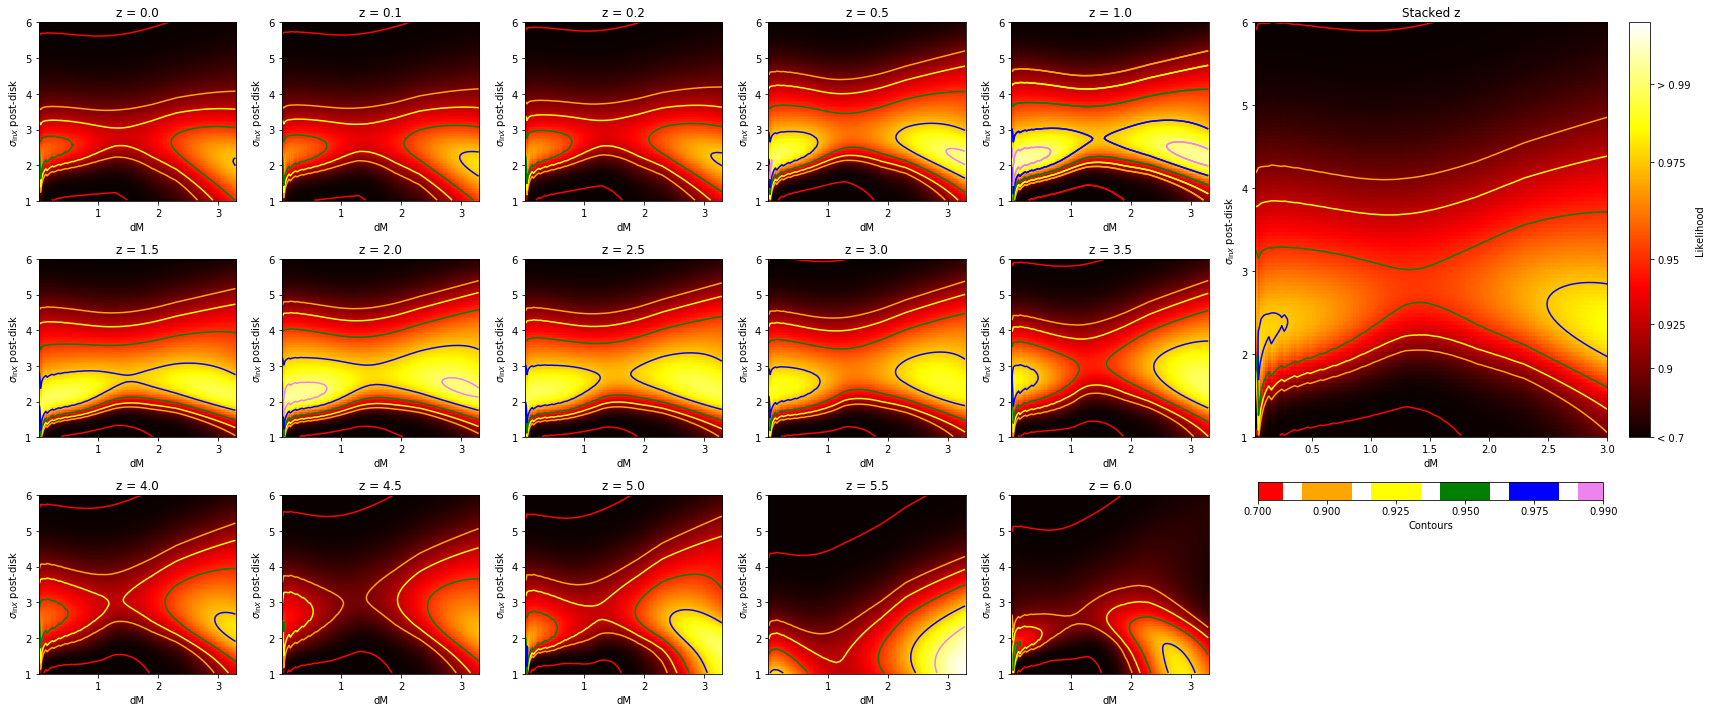

In [24]:
plt.close()

ticks = [0.70,0.90,0.925,0.95,0.975,0.99]
ticklabels = [str(i) for i in ticks]
ticklabels[0] = '< '+ticklabels[0]
ticklabels[-1] = '> '+ticklabels[-1]

gridcmap = 'hot'
contcmap = 'Pastel1'
contmin = 0.7
colors = ['red','orange','yellow','green','blue','violet']
gam=8

f = h5py.File("QUEST/data/chi2_2equiweight.h5py", "r")
dM = f['dM'][:]
siglnX2 = f['siglnX2'][:]
f.close()

extent = [dM[0], dM[-1], siglnX2[-1], siglnX2[0]]

totpoints = 732

fig = plt.figure(figsize=(24,10))
gs = gridspec.GridSpec(3, 7)
stack = np.zeros((len(dM), len(dM)))
zlist = [0.0, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,0,1,1,1,1,1,2,2,2,2,2],[0,1,2,3,4,0,1,2,3,4,0,1,2,3,4]):
    
    
    xa, ya, yerr = grab_obs(z)
    num_obs = len(xa)
    f = h5py.File("QUEST/data/chi2_2equiweight.h5py", "r")
    grid2d = np.transpose(f['z='+str(z)+'/chi2_grid'][:])
    numob = f['z='+str(z)+'/#_observation'][:][0]
    f.close()
    
    maxval = max(map(max, grid2d))

    ax = fig.add_subplot(gs[i, j])
    img = ax.imshow(np.e**(-grid2d/maxval), cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=gam), vmin = .5, vmax = 1)
    ax.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
    ax.set_xlabel('dM')
    ax.axis([0.01,3.3,1,6])
    ax.set_title('z = '+str(z))
    plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)
    if z == 1.0:
        cont1 = plt.contour(np.e**(-grid2d/maxval), colors=colors, extent = extent, origin = 'image', levels=ticks)

    stack += np.e**(-grid2d/maxval) * (numob/totpoints)

    

ax1 = fig.add_subplot(gs[0:2,5:])

total = ax1.imshow(stack, cmap = gridcmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=gam), vmin = .5, vmax = 1)
ax1.set_ylabel(r'$\sigma_{\ln{X}}$ post-disk')
ax1.set_xlabel('dM')
ax1.axis([0.01,3,1,6])
ax1.set_title('Stacked z')


cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05, ticks = ticks)
cbar.ax.set_yticklabels(ticklabels)
cont = ax1.contour(stack, colors=colors, extent = extent, origin = 'image', levels=ticks)
axx1 = plt.axes([.73, .3, .2, .025])
cbar = plt.colorbar(cont1, cax = axx1, ticks = ticks, orientation='horizontal', label='Contours')

lines = cbar.ax.get_children()[0]
lines.set_linewidths([50]*len(lines.get_linewidths()))

plt.tight_layout()
plt.savefig('plots/paper-plots/chi2_2equiweight.pdf')


/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:214: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:218: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


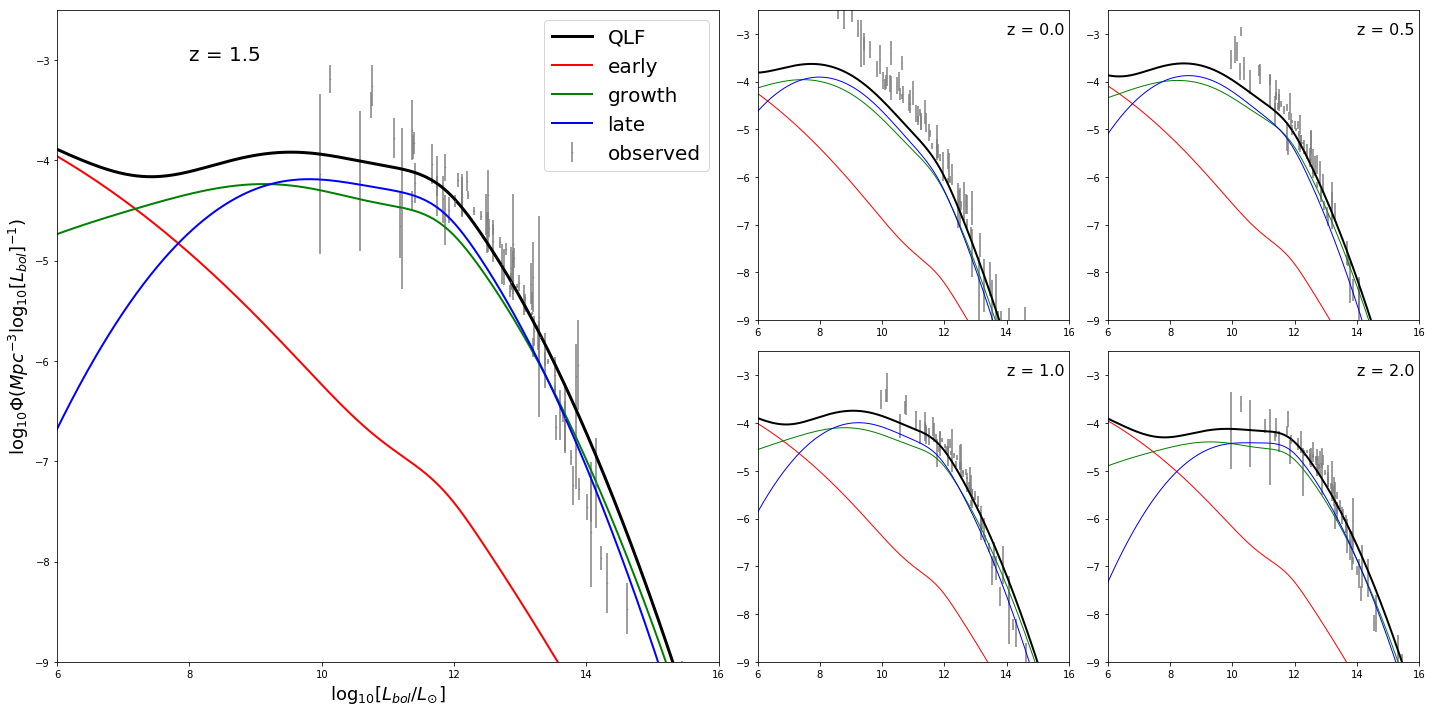

In [12]:
fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(2, 4)
lums = np.linspace(5,18,1000)
z = 1.5
siglnX = [5,2.5]
ax1 = fig.add_subplot(gs[0:, 0:2])
qlf = QLF(z, 0.01)
qlf.get_dNdlnMstar(0.7)
qlf.get_SMBM(0.3)
qlf.get_dNdlnL(lums, siglnX)
xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
ax1.plot(xm, ym, c='k',lw=3, label='QLF')

totearly = []
totgrowth = []
totlate = []

for i, o in zip(qlf.intvals, qlf.FOb):
    totearly.append((1-o) * np.sum(i[qlf.early]))
    totgrowth.append((1-o) * np.sum(i[qlf.growth]))
    totlate.append((1-o) * np.sum(i[qlf.late]))

ax1.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r', label='early',lw=2)
ax1.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green', label='growth',lw=2)
ax1.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b', label='late',lw=2)


x, y , yerr = grab_obs(z)
ax1.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5, c='gray', label = 'observed')

ax1.axis([6,16,-9,-2.5])
ax1.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax1.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)
ax1.legend(fontsize = 20)
ax1.text(8,-3, 'z = '+str(z), fontsize = 20)


for z, i, j in zip([0.0,0.5,1.0,2.0],[0,0,1,1],[2,3,2,3]):
    ax = fig.add_subplot(gs[i, j], sharex = ax1, sharey = ax1)
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_SMBM(0.3)
    qlf.get_dNdlnL(lums, siglnX)
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k',lw=2)

    totearly = []
    totgrowth = []
    totlate = []

    for i, o in zip(qlf.intvals, qlf.FOb):
        totearly.append((1-o) * np.sum(i[qlf.early]))
        totgrowth.append((1-o) * np.sum(i[qlf.growth]))
        totlate.append((1-o) * np.sum(i[qlf.late]))

    ax.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r', label='early',lw=1)
    ax.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green', label='growth',lw=1)
    ax.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b', label='late',lw=1)


    x, y , yerr = grab_obs(z)
    ax.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
    ax.axis([6,16,-9,-2.5])
    ax.text(14,-3, 'z = '+str(z), fontsize = 16)
plt.tight_layout()
plt.savefig('plots/paper-plots/QLF_byeye_lowz.pdf')

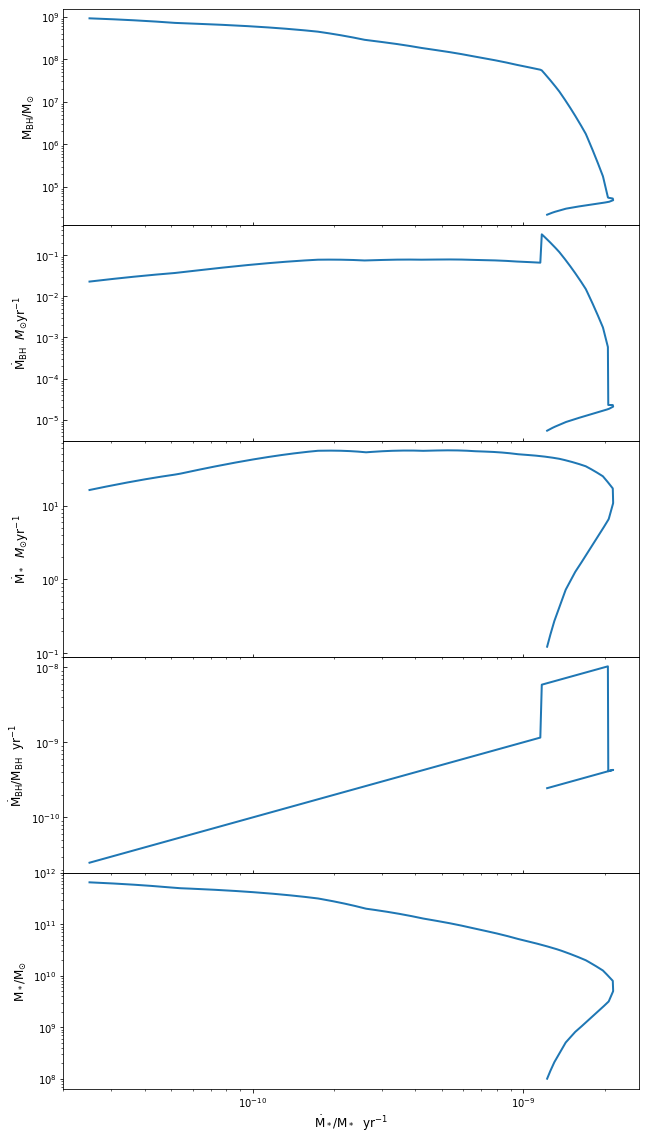

In [17]:
# qlf = QLF(1.5, 500)
# qlf.get_dNdlnMstar(0.7)
# qlf.get_SMBM(0.3)
# qlf.LumBins = np.linspace(6,18,1000)
# qlf.get_dNdlnL([5,3])
# MdotBH = np.e**(qlf.Mdot_mu_sig[:,3])/(3.17098e-8*2e33) ## Mdot yr-1
# MdotStar = np.e**qlf.Mdot_mu_sig[:,5] * 10**(qlf.StellBins)
# SSFR = np.e**qlf.Mdot_mu_sig[:,5]
# SBHR = np.e**qlf.Mdot_mu_sig[:,4] * 3.154e7
# Mbh = 10**(qlf.StellBins * qlf.m + qlf.b)
#Mstar = 10**qlf.StellBins

y_list1 = [SSFR, SBHR, MdotStar, MdotBH, Mbh]
x1, file1, xlabel1 = Mstar, 'Mstar', r'$\rmM_*/M_{\odot}$'
y_list2 = [SSFR, SBHR, MdotStar, MdotBH, Mstar]
x2, file2, xlabel2 = Mbh, 'Mbh', r'$\rmM_{\rmBH}/M_{\odot}$'
y_list3 = [SSFR, SBHR, MdotStar, Mstar, Mbh]
x3, file3, xlabel3 = MdotBH, 'MdotBH', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$'
y_list4 = [SSFR, SBHR, Mstar, MdotBH, Mbh]
x4, file4, xlabel4 = MdotStar, 'MdotStar', r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$'
y_list5 = [SSFR, Mstar, MdotStar, MdotBH, Mbh]
x5, file5, xlabel5 = SBHR, 'SBHR', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$'
y_list6 = [Mstar, SBHR, MdotStar, MdotBH, Mbh]
x6, file6, xlabel6 = SSFR, 'SSFR', r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$'

label_list1 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_{\rmBH}/M_{\odot}$']
label_list2 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_*/M_{\odot}$']
label_list3 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_*/M_{\odot}$', r'$\rmM_{\rmBH}/M_{\odot}$']
label_list4 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\rmM_*/M_{\odot}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_{\rmBH}/M_{\odot}$']
label_list5 = [r'$\dot{\rmM}_*/\rmM_* \ \ \rmyr^{-1}$', r'$\rmM_*/M_{\odot}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_{\rmBH}/M_{\odot}$']
label_list6 = [r'$\rmM_*/M_{\odot}$', r'$\dot{\rmM}_{\rmBH}/\rmM_{\rmBH} \ \ \rmyr^{-1}$',\
              r'$\dot{\rmM}_* \ \ M_{\odot} \rmyr^{-1}$', r'$\dot{\rmM}_{\rmBH} \ \ M_{\odot} \rmyr^{-1}$', r'$\rmM_{\rmBH}/M_{\odot}$']

y_lists = [y_list1, y_list2, y_list3, y_list4, y_list5, y_list6,]
xs = [x1, x2, x3, x4, x5, x6]
files = [file1, file2, file3, file4, file5, file6]
xlabels = [xlabel1, xlabel2, xlabel3, xlabel4, xlabel5, xlabel6]
label_lists = [label_list1, label_list2, label_list3, label_list4, label_list5, label_list6]

lw = 2
fs = 12

for y_list, x, file, xlabel, label_list in zip(y_lists, xs, files, xlabels, label_lists):
    plt.close('all')
    fig = plt.figure(figsize=(10,20))

    ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.15])
    ax2 = fig.add_axes([0.1, 0.25, 0.8, 0.15], sharex = ax1)
    ax3 = fig.add_axes([0.1, 0.4, 0.8, 0.15], sharex = ax1)
    ax4 = fig.add_axes([0.1, 0.55, 0.8, 0.15], sharex = ax1)
    ax5 = fig.add_axes([0.1, 0.70, 0.8, 0.15], sharex = ax1)
    for ax, y, label in zip([ax1, ax2, ax3, ax4, ax5], y_list, label_list):

        ax.plot(x, y, lw = lw)
        ax.set_ylabel(label, fontsize = fs)
        ax.set_yscale('log')
        ax.set_xscale('log')

        if ax != ax1:
            ax.tick_params(direction='in')
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            ax.set_xlabel(xlabel, fontsize = fs)

    plt.savefig('plots/paper-plots/accretion_'+file+'.pdf')

10.600000000000001


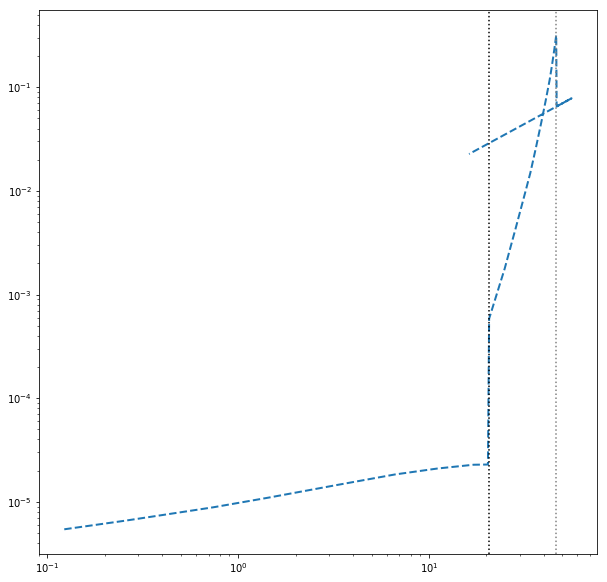

In [47]:
fig = plt.figure(figsize=(10,10))
qlf = QLF(1.5, 500)
qlf.get_dNdlnMstar(0.7)
qlf.get_SMBM(0.3)
qlf.LumBins = np.linspace(6,18,1000)
qlf.get_dNdlnL([5,3])
MdotBH = np.e**(qlf.Mdot_mu_sig[:,3])/(3.17098e-8*2e33) ## Mdot yr-1
MdotStar = np.e**qlf.Mdot_mu_sig[:,5] * 10**(qlf.StellBins)
SSFR = np.e**qlf.Mdot_mu_sig[:,5]
SBHR = np.e**qlf.Mdot_mu_sig[:,4] * 3.154e7
Mbh = 10**(qlf.StellBins * qlf.m + qlf.b)
Mstar = 10**qlf.StellBins
mass_cuts = qlf.mass_cuts
print(qlf.mass_cuts[1])
cut1 = np.argmin(np.abs(Mstar - 10**mass_cuts[0]))
cut2 = np.argmin(np.abs(Mstar - 10**mass_cuts[1]))


plt.plot(MdotStar, MdotBH, lw=2, linestyle='dashed')
plt.axvline(MdotStar[cut1], c='k', linestyle='dotted')
plt.axvline(MdotStar[cut2], c='gray', linestyle='dotted')
plt.xscale('log')
plt.yscale('log')

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:214: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:218: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


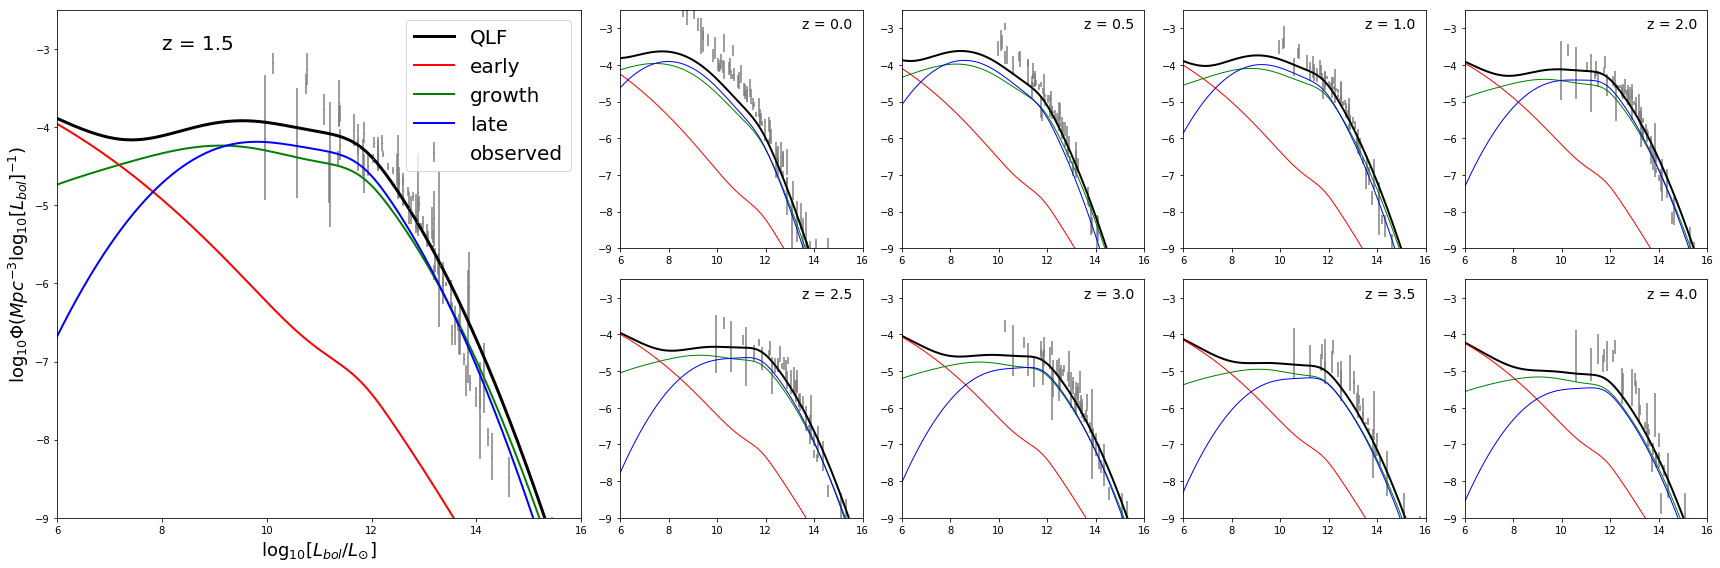

In [18]:
fig = plt.figure(figsize=(24,8))
gs = gridspec.GridSpec(2, 6)
lums = np.linspace(5,18,1000)
z = 1.5
siglnX = [5,2.5]
ax1 = fig.add_subplot(gs[0:, 0:2])
qlf = QLF(z, 0.01)
qlf.get_dNdlnMstar(0.7)
qlf.get_SMBM(0.3)
qlf.get_dNdlnL(lums, siglnX)
xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
ax1.plot(xm, ym, c='k',lw=3, label='QLF')

totearly = []
totgrowth = []
totlate = []

for i, o in zip(qlf.intvals, qlf.FOb):
    totearly.append((1-o) * np.sum(i[qlf.early]))
    totgrowth.append((1-o) * np.sum(i[qlf.growth]))
    totlate.append((1-o) * np.sum(i[qlf.late]))

ax1.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r', label='early',lw=2)
ax1.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green', label='growth',lw=2)
ax1.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b', label='late',lw=2)


x, y , yerr = grab_obs(z)
ax1.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5, c='gray', label = 'observed')

ax1.axis([6,16,-9,-2.5])
ax1.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax1.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)
ax1.legend(fontsize = 20)
ax1.text(8,-3, 'z = '+str(z), fontsize = 20)


for z, i, j in zip([0.0,0.5,1.0,2.0,2.5,3.0,3.5,4.0],[0,0,0,0,1,1,1,1],[2,3,4,5,2,3,4,5]):
    ax = fig.add_subplot(gs[i, j], sharex = ax1, sharey = ax1)
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_SMBM(0.3)
    qlf.get_dNdlnL(lums, siglnX)
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k',lw=2)

    totearly = []
    totgrowth = []
    totlate = []

    for i, o in zip(qlf.intvals, qlf.FOb):
        totearly.append((1-o) * np.sum(i[qlf.early]))
        totgrowth.append((1-o) * np.sum(i[qlf.growth]))
        totlate.append((1-o) * np.sum(i[qlf.late]))

    ax.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r', label='early',lw=1)
    ax.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green', label='growth',lw=1)
    ax.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b', label='late',lw=1)


    x, y , yerr = grab_obs(z)
    ax.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
    ax.axis([6,16,-9,-2.5])
    ax.text(13.5,-3, 'z = '+str(z), fontsize = 14)
plt.tight_layout()
plt.savefig('plots/paper-plots/QLF_byeye_lotz.pdf')

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:214: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:218: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


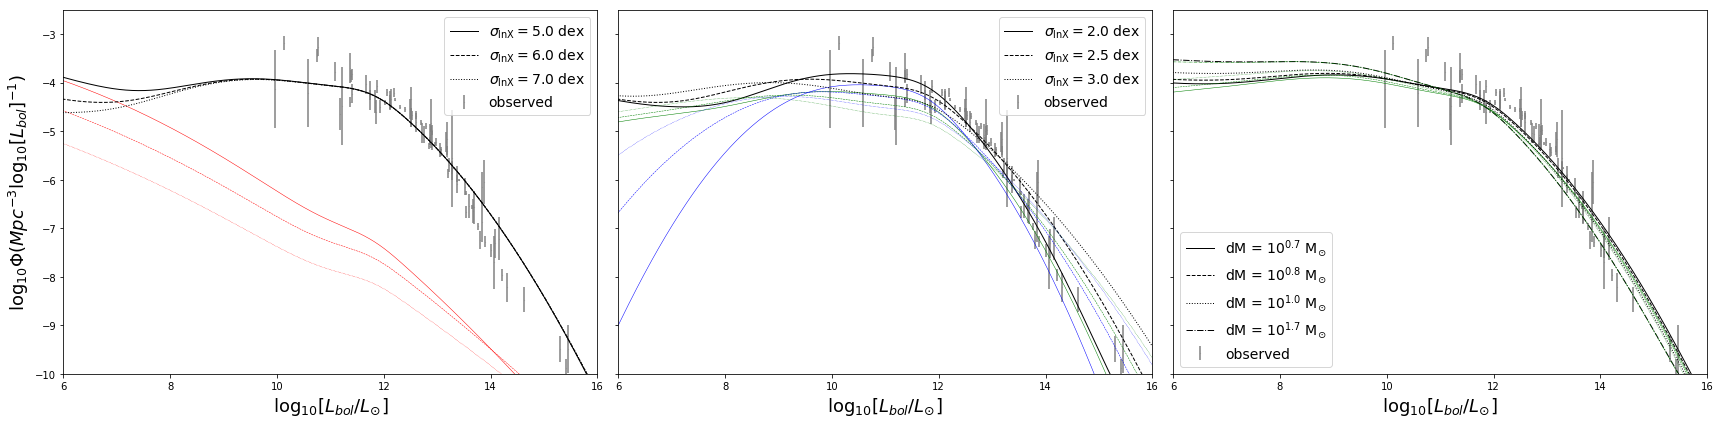

In [28]:
fig = plt.figure(figsize=(24,6))
gs = gridspec.GridSpec(1, 3)
lums = np.linspace(5,18,1000)
z = 1.5
qlf = QLF(z, 0.01)
x, y , yerr = grab_obs(z)
lines = ['solid','dashed','dotted','dashdot']
ax = fig.add_subplot(gs[0, 0])
for xsig1, ls in zip([5.0,6.0,7.0], lines):
    qlf.get_dNdlnMstar(0.7)
    qlf.get_SMBM(0.3)
    qlf.get_dNdlnL(lums, [xsig1, 2.5])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k',lw=1, label=r'$\sigma_{\ln \rmX} = $'+str(xsig1)+' dex', ls = ls)

    totearly = []
    totgrowth = []
    totlate = []

    for i, o in zip(qlf.intvals, qlf.FOb):
        totearly.append((1-o) * np.sum(i[qlf.early]))
        totgrowth.append((1-o) * np.sum(i[qlf.growth]))
        totlate.append((1-o) * np.sum(i[qlf.late]))

    ax.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r',lw=0.5, ls=ls)
ax.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax.legend(fontsize=14)
ax.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)
ax.axis([6,16,-10,-2.5])


ax1 = fig.add_subplot(gs[0, 1], sharex = ax, sharey = ax)
for xsig2, ls in zip([2.0, 2.5, 3.0], lines):
    qlf.get_dNdlnMstar(0.7)
    qlf.get_SMBM(0.3)
    qlf.get_dNdlnL(lums, [6.0, xsig2])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax1.plot(xm, ym, c='k',lw=1, label=r'$\sigma_{\ln \rmX} = $'+str(xsig2)+' dex', ls = ls)

    totearly = []
    totgrowth = []
    totlate = []

    for i, o in zip(qlf.intvals, qlf.FOb):
        totearly.append((1-o) * np.sum(i[qlf.early]))
        totgrowth.append((1-o) * np.sum(i[qlf.growth]))
        totlate.append((1-o) * np.sum(i[qlf.late]))

    ax1.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green',lw=0.5,ls=ls)
    ax1.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b',lw=0.5, ls=ls)
ax1.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax1.legend(fontsize=14)
ax1.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax1.axis([6,16,-10,-2.5])


ax2 = fig.add_subplot(gs[0, 2], sharex = ax, sharey = ax)
for dM, ls in zip([0.7,0.8,1.0, 1.7], lines):
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(lums, [6.0, 2.5])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax2.plot(xm, ym, c='k', lw=1, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$', ls = ls)

    totearly = []
    totgrowth = []
    totlate = []

    for i, o in zip(qlf.intvals, qlf.FOb):
        totearly.append((1-o) * np.sum(i[qlf.early]))
        totgrowth.append((1-o) * np.sum(i[qlf.growth]))
        totlate.append((1-o) * np.sum(i[qlf.late]))

    ax2.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green',lw=0.5,ls=ls)

ax2.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax2.legend(fontsize=14)
ax2.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax2.axis([6,16,-10,-2.5])

plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.tight_layout()
#plt.savefig('plots/paper-plots/free_param_effects.pdf')

In [27]:
%matplotlib widget
fig = plt.figure(figsize=(22,4))
gs = gridspec.GridSpec(1, 4)
lums = np.linspace(5,18,1000)
z = 1.5
qlf = QLF(z, 0.01)
x, y , yerr = grab_obs(z)
lines = ['solid','dashed','dotted','dashdot']

ax = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharex = ax, sharey = ax)
ax2 = fig.add_subplot(gs[0, 2], sharex = ax, sharey = ax)
ax3 = fig.add_subplot(gs[0, 3], sharex = ax, sharey = ax)
# ax4 = fig.add_subplot(gs[0, 4])

for dM, ls in zip([0.3, 1.7, 3.3], lines):
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(lums, [6.0, 2.5])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k', lw=1, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$', ls = ls)
    
    totearly = []
    totgrowth = []
    totlate = []

    for i, o in zip(qlf.intvals, qlf.FOb):
        totearly.append((1-o) * np.sum(i[qlf.early]))
        totgrowth.append((1-o) * np.sum(i[qlf.growth]))
        totlate.append((1-o) * np.sum(i[qlf.late]))
#     Mdotbh = qlf.Mdot_mu_sig[:,0]
    ax1.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r',lw=1, ls=ls, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
    ax2.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='g',lw=1, ls=ls, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
    ax3.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b',lw=1, ls=ls, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
#     ax4.plot(np.log(np.e**Mdotbh/(3.17098e-8*2e33)), qlf.Mdot_mu_sig[:,1], lw=1, ls=ls, label=r'dM = $10^{'+str(dM)+'}$ M$_{\odot}$')
ax.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax.legend(fontsize=14)
ax1.legend(fontsize=14)
ax2.legend(fontsize=14)
ax3.legend(fontsize=14)
# ax4.legend(fontsize=14)
ax.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=14)
ax1.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=14)
ax2.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=14)
ax3.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=14)
# ax4.set_xlabel(r'$\dot{\rmM}_{\rmBH}/\rmM_{\odot} $yr$^{-1}$', fontsize=14)
ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =14)
# ax4.set_ylabel(r'$\sigma_{\ln \rmX}$ (dex)')
ax.axis([6,16,-10,-3])




plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
plt.tight_layout()
plt.savefig('plots/paper-plots/free_param_effects_dM.pdf')

FigureCanvasNbAgg()

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:214: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:218: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:35: RuntimeWarning: divide by zero encountered in log10
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:33: RuntimeWarning: divide by zero encountered in log10


/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:214: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:218: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


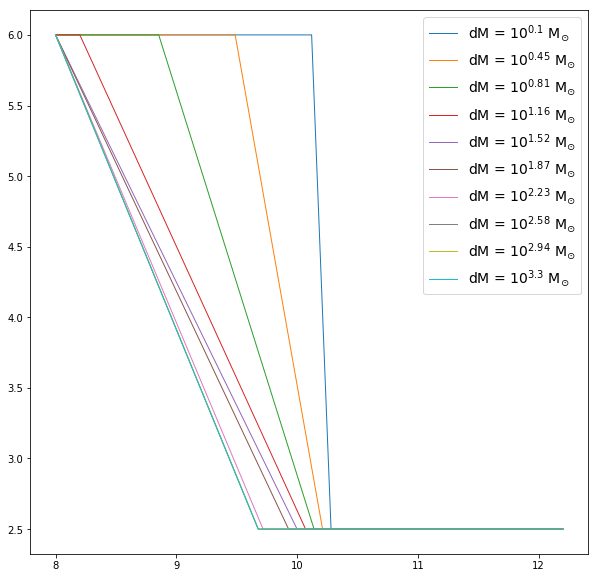

In [5]:
fig = plt.figure(figsize=(10,10))
lums = np.linspace(6,18,500)
for dM in np.linspace(0.1,3.3,10):
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(lums, [6.0, 2.5])
    Mdotbh = qlf.Mdot_mu_sig[:,0]
    plt.plot(qlf.StellBins, qlf.Mdot_mu_sig[:,1], lw=1, label=r'dM = $10^{'+str(dM)[0:4]+'}$ M$_{\odot}$')
    plt.legend(fontsize=14)